# Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mofax as mfx


c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load data

In [61]:
mrna_data = pd.read_csv('../../data/cleaned_data/mrna_cleaned.csv', index_col=0)
mrna_data_lg2 = pd.read_csv('../../data/transformed_data/mrna_data_lg2.csv', index_col=0)
mrna_data_vsn = pd.read_csv('../../data/transformed_data/mrna_data_vsn.csv', index_col=0)
mrna_data_lg2_fs = pd.read_csv('../../data/feature_selection/selected_features_mrna_data_lg2.csv', index_col=0)
mrna_data_vsn_fs = pd.read_csv('../../data/feature_selection/selected_features_mrna_data_vsn.csv', index_col=0)

In [2]:
mirna_data = pd.read_csv('../../data/cleaned_data/mirna_cleaned.csv', index_col=0)
mirna_data_lg2 = pd.read_csv('../../data/transformed_data/mirna_data_lg2.csv', index_col=0)
mirna_data_vsn = pd.read_csv('../../data/transformed_data/mirna_data_vsn.csv', index_col=0)
mirna_data_lg2_fs = pd.read_csv('../../data/feature_selection/selected_features_mirna_data_lg2.csv', index_col=0)
mirna_data_vsn_fs = pd.read_csv('../../data/feature_selection/selected_features_mirna_data_vsn.csv', index_col=0)

In [63]:
meth_data = pd.read_csv('../../data/cleaned_data/meth_cleaned.csv', index_col=0)
meth_data_m = pd.read_csv('../../data/transformed_data/meth_data_m_values.csv', index_col=0)
meth_data_fs = pd.read_csv('../../data/feature_selection/selected_features_meth_data.csv', index_col=0)

In [64]:
clinical_data = pd.read_csv('../../data/cleaned_data/clinical_cleaned.csv', index_col=0)

UMAP function

In [65]:
def umap_function(df, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42, title='UMAP Projection'):
    umap_model = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=random_state)
    embedding = umap_model.fit_transform(df)
    plt.figure(figsize=(6, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=18, alpha = 0.8)
    plt.title(title)
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.show()
    return embedding

#### UMAP on mrna_data, mrna_data_lg2 and mrna_data_vsn

In [66]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embedding_mrna = umap_model.fit_transform(mrna_data)
embedding_mrna_lg2 = umap_model.fit_transform(mrna_data_lg2)
embedding_mrna_lg2_fs = umap_model.fit_transform(mrna_data_lg2_fs)
embedding_mrna_vsn = umap_model.fit_transform(mrna_data_vsn)
embedding_mrna_vsn_fs = umap_model.fit_transform(mrna_data_vsn_fs)

c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [67]:
subtype = clinical_data.loc[mrna_data.index, 'tumor_subtype']

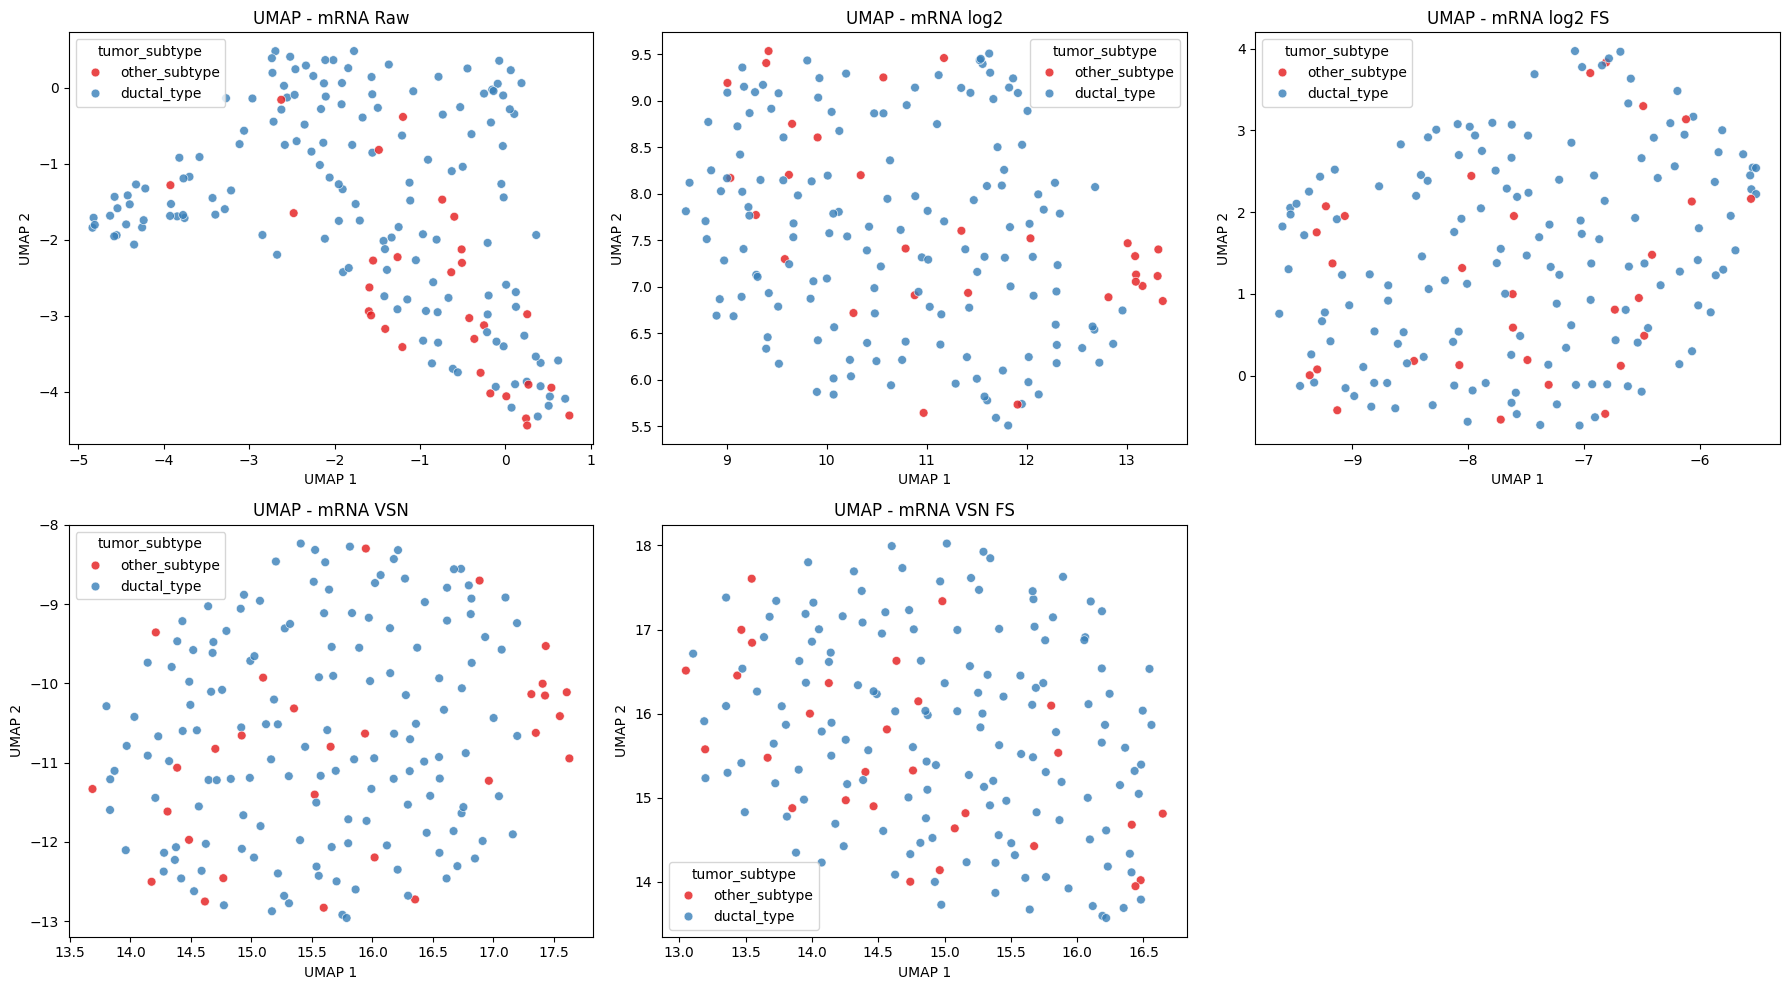

In [68]:
hue_orders = ['other_subtype', 'ductal_type']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plots = [
    (embedding_mrna, 'UMAP - mRNA Raw'),
    (embedding_mrna_lg2, 'UMAP - mRNA log2'),
    (embedding_mrna_lg2_fs, 'UMAP - mRNA log2 FS'),
    (embedding_mrna_vsn, 'UMAP - mRNA VSN'),
    (embedding_mrna_vsn_fs, 'UMAP - mRNA VSN FS')
]

for i, (embedding, title) in enumerate(plots):
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=subtype,
        palette='Set1',
        hue_order=hue_orders,
        s=40,
        alpha=0.8,
        ax=axes[i]
    )
    axes[i].set_title(title)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')

axes[5].axis('off')

plt.tight_layout()
plt.show()


#### UMAP on mirna_data, mirna_data_lg2 and mirna_data_vsn

In [69]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embedding_mirna = umap_model.fit_transform(mirna_data)
embedding_mirna_lg2 = umap_model.fit_transform(mirna_data_lg2)
embedding_mirna_lg2_fs = umap_model.fit_transform(mirna_data_lg2_fs)
embedding_mirna_vsn = umap_model.fit_transform(mirna_data_vsn)
embedding_mirna_vsn_fs = umap_model.fit_transform(mirna_data_vsn_fs)

c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [70]:
subtype = clinical_data.loc[mirna_data.index, 'tumor_subtype']

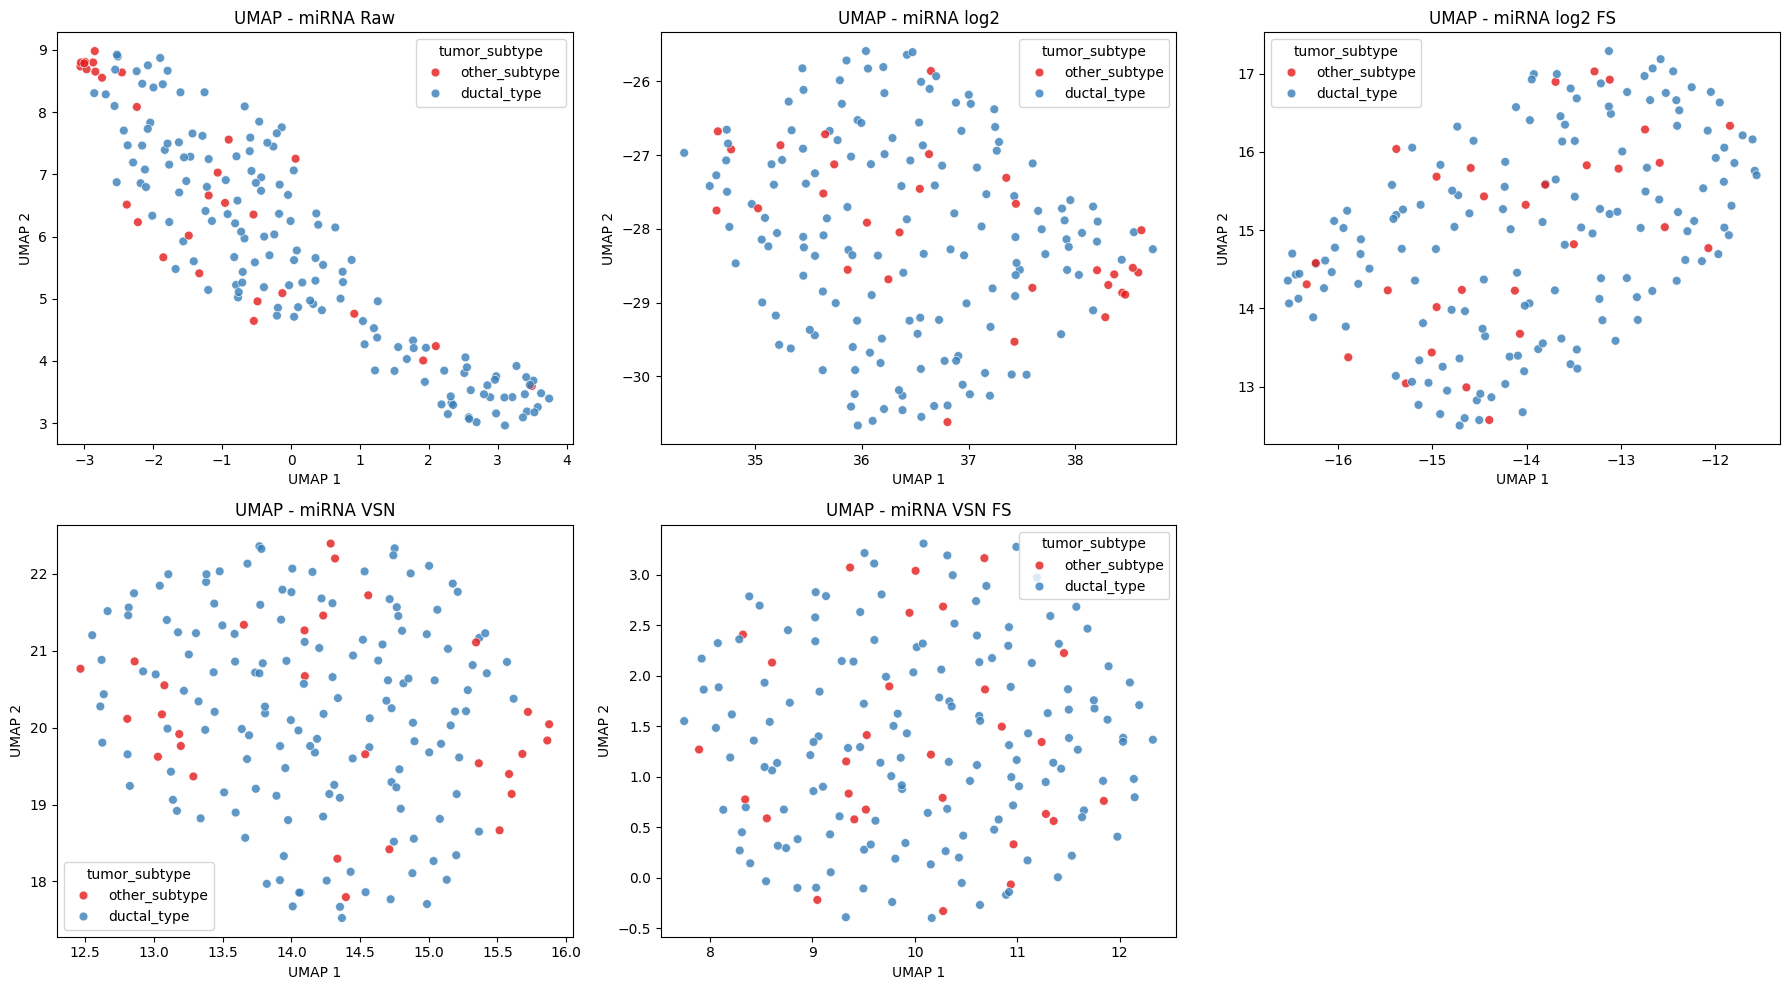

In [71]:
hue_orders = ['other_subtype', 'ductal_type']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plots = [
    (embedding_mirna, 'UMAP - miRNA Raw'),
    (embedding_mirna_lg2, 'UMAP - miRNA log2'),
    (embedding_mirna_lg2_fs, 'UMAP - miRNA log2 FS'),
    (embedding_mirna_vsn, 'UMAP - miRNA VSN'),
    (embedding_mirna_vsn_fs, 'UMAP - miRNA VSN FS')
]

for i, (embedding, title) in enumerate(plots):
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=subtype,
        palette='Set1',
        hue_order=hue_orders,
        s=40,
        alpha=0.8,
        ax=axes[i]
    )
    axes[i].set_title(title)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')

axes[5].axis('off')

plt.tight_layout()
plt.show()


#### UMAP on meth_data, meth_data_m and meth_data_fs

In [72]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embedding_meth = umap_model.fit_transform(meth_data)
embedding_meth_m = umap_model.fit_transform(meth_data_m)
embedding_meth_fs = umap_model.fit_transform(meth_data_fs)

c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [73]:
subtype = clinical_data.loc[meth_data.index, 'tumor_subtype']

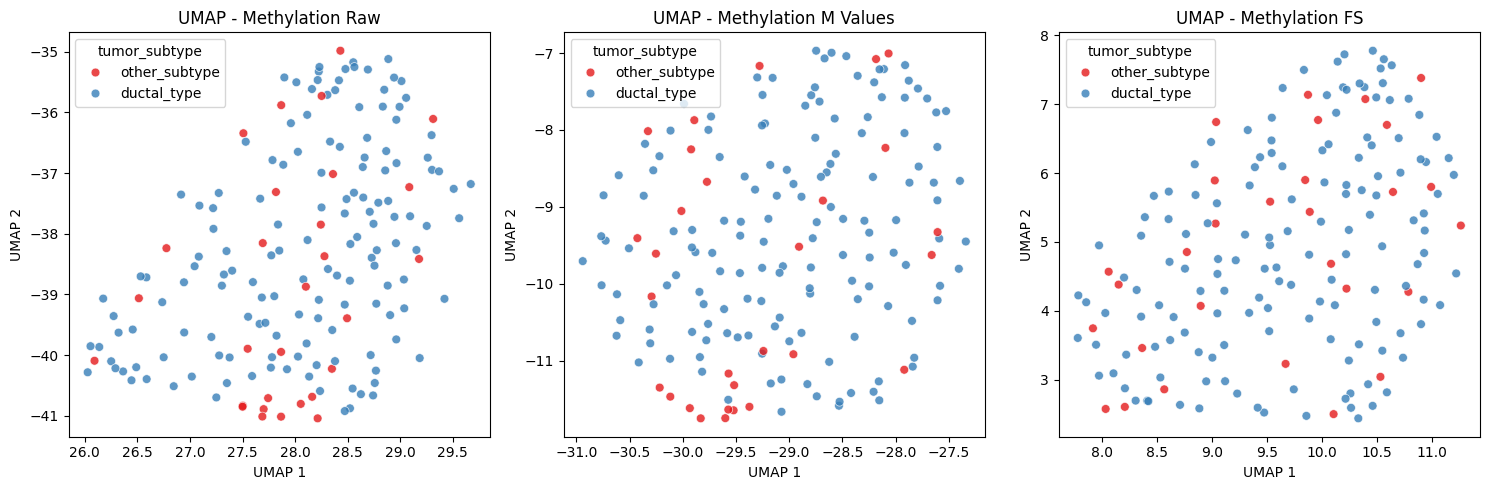

In [74]:
hue_orders = ['other_subtype', 'ductal_type']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex = False, sharey = False)

plots = [(embedding_meth, 'UMAP - Methylation Raw'),
         (embedding_meth_m, 'UMAP - Methylation M Values'),
         (embedding_meth_fs, 'UMAP - Methylation FS')]

for i, (embedding, title) in enumerate(plots):
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=subtype, palette = 'Set1', hue_order = hue_orders, s=40, alpha=0.8, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')


plt.tight_layout()
plt.show()

MOFA

In [75]:
def load_mofa_factors(model_path, clinical_index):
    model = mfx.mofa_model(model_path)
    factors = model.get_factors(df=True)
    factors = factors.loc[clinical_index]
    return factors

In [76]:
subtype = clinical_data["tumor_subtype"]
mofa_lg2 = load_mofa_factors("../../data/latent/mofa_trained_lg2.hdf5", clinical_data.index)
mofa_lg2_fs = load_mofa_factors("../../data/latent/mofa_trained_lg2_fs.hdf5", clinical_data.index)
mofa_vsn = load_mofa_factors("../../data/latent/mofa_trained_vsn.hdf5", clinical_data.index)
mofa_vsn_fs = load_mofa_factors("../../data/latent/mofa_trained_vsn_fs.hdf5", clinical_data.index)


Concatenar datasets antes de fs e umap

In [77]:
def concatenate_omics(*dfs):
    common_index = dfs[0].index
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)

    aligned_dfs = [df.loc[common_index] for df in dfs]
    concatenated_df = pd.concat(aligned_dfs, axis=1)

    return concatenated_df


In [78]:
meth_data_m.shape

(176, 194313)

In [79]:
concat_lg2 = concatenate_omics(
    mrna_data_lg2,
    mirna_data_lg2,
    meth_data_m
)



In [80]:
concat_lg2_fs = concatenate_omics(
    mrna_data_lg2_fs,
    mirna_data_lg2_fs,
    meth_data_fs
)

In [81]:
concat_vsn = concatenate_omics(
    mrna_data_vsn,
    mirna_data_vsn,
    meth_data_m
)

In [82]:
concat_vsn_fs = concatenate_omics(
    mrna_data_vsn_fs,
    mirna_data_vsn_fs,
    meth_data_fs
)

In [83]:
representations_lg2 = {
    "Concat lg2": concat_lg2,
    "Concat lg2 FS": concat_lg2_fs,
    "MOFA lg2": mofa_lg2,
    "MOFA lg2 FS": mofa_lg2_fs,
}

c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


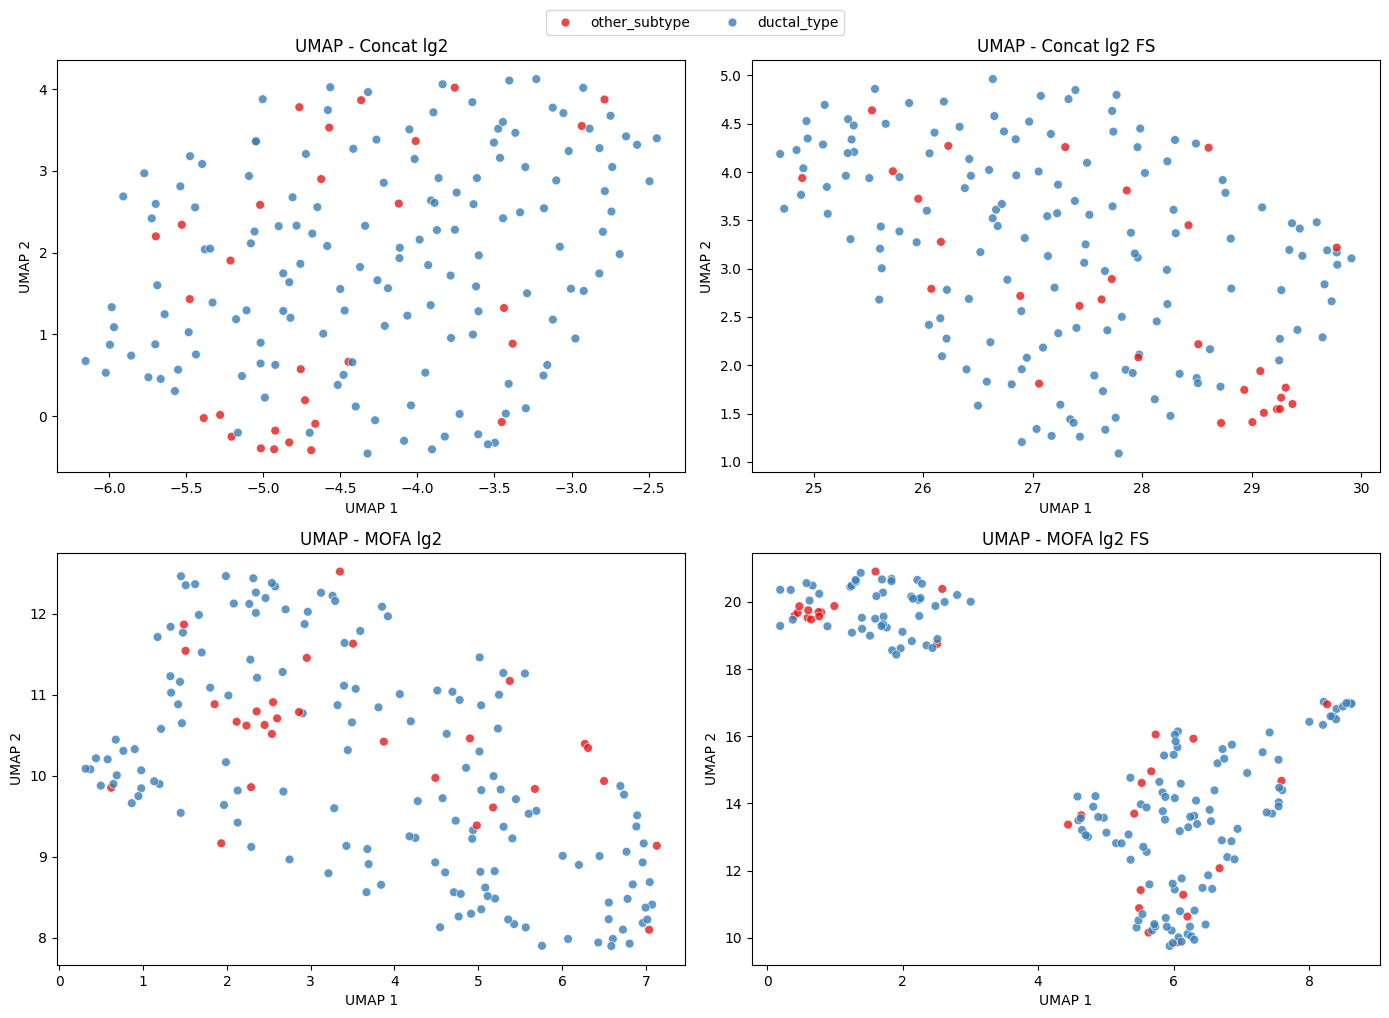

In [84]:
hue_orders = ['other_subtype', 'ductal_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(representations_lg2.items()):
    aligned_df = df.loc[clinical_data.index.intersection(df.index)]
    aligned_subtype = subtype.loc[aligned_df.index]

    umap_model = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )

    embedding = umap_model.fit_transform(aligned_df)

    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=aligned_subtype,
        palette='Set1',
        hue_order=hue_orders,
        s=40,
        alpha=0.8,
        ax=axes[i]
    )

    axes[i].set_title(f"UMAP - {name}")
    axes[i].set_xlabel("UMAP 1")
    axes[i].set_ylabel("UMAP 2")

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()


In [85]:
representations_vsn = {
    "Concat VSN": concat_vsn,
    "Concat VSN FS": concat_vsn_fs,
    "MOFA VSN": mofa_vsn,
    "MOFA VSN FS": mofa_vsn_fs,
}

c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ritam\Desktop\thesis_rita\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


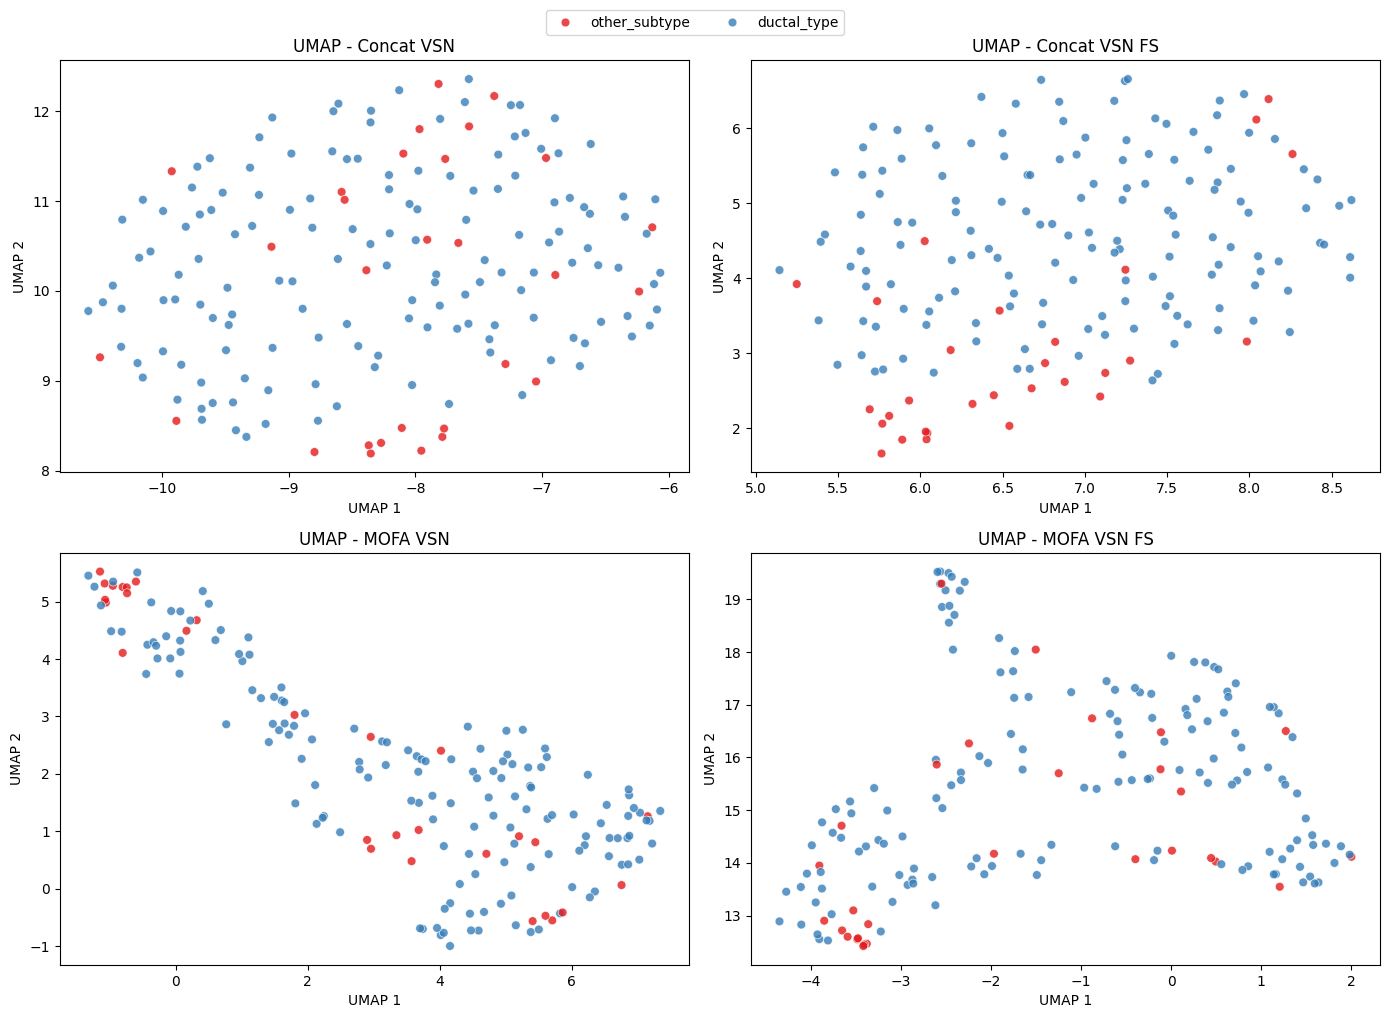

In [86]:
hue_orders = ['other_subtype', 'ductal_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(representations_vsn.items()):
    aligned_df = df.loc[clinical_data.index.intersection(df.index)]
    aligned_subtype = subtype.loc[aligned_df.index]

    umap_model = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )

    embedding = umap_model.fit_transform(aligned_df)

    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=aligned_subtype,
        palette='Set1',
        hue_order=hue_orders,
        s=40,
        alpha=0.8,
        ax=axes[i]
    )

    axes[i].set_title(f"UMAP - {name}")
    axes[i].set_xlabel("UMAP 1")
    axes[i].set_ylabel("UMAP 2")

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()
